# spatial aware sink token analysis

this notebook checks whether sink attention depends on the spatial position of the triangle being generated, and whether spatially placed scaffold sinks would help. the earlier idea was to replace the single bos sink with several scaffold sinks scattered in space.

## setup

- purpose: load the recorded attention and generated tokens and rebuild the mesh geometry that the experiments read
- method:
  - the attention was saved as a 1d row per step, already reduced to what the last token attends to, so no extra reduction is done here
  - `tokens_to_triangles` inverts the 128 level discretization to coordinates and groups every 9 values into a triangle, then each triangle center is the mean of its 3 vertices
- output: prints the attention shape, the snapshot count, and the triangle and centroid shapes

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
import pickle
import os

# use gpu if present, else cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# folder for saved figures
OUTPUT_DIR = 'spatial_sink_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# attention was saved as a 1d row per step, already the last token row over all earlier tokens
with open('captured_attentions_all.pkl', 'rb') as f:
    captured_attentions = pickle.load(f)

# check the stored shape on one sample at layer 23
sample_step = list(captured_attentions.keys())[0]
sample_attn = captured_attentions[sample_step][23]
print(f'sample attention shape: {sample_attn.shape}')
print(f'attention is 1D: {sample_attn.ndim == 1}')

generated_tokens = np.load('generated_tokens.npy')
n_triangles = len(generated_tokens) // 9

print(f'loaded {len(captured_attentions)} attention snapshots')
print(f'total triangles: {n_triangles}')

sample attention shape: (28,)
attention is 1D: True
loaded 489 attention snapshots
total triangles: 492


In [3]:
def tokens_to_triangles(tokens, n_discrete=128):
    # map token ids back to coordinates in the range -1 to 1, then group every 9 into a triangle
    n_tri = len(tokens) // 9
    triangles = []
    for i in range(n_tri):
        tri_tokens = tokens[i*9:(i+1)*9]
        coords = (tri_tokens / (n_discrete - 1)) * 2 - 1
        triangles.append(coords.reshape(3, 3))
    return np.array(triangles)

triangles = tokens_to_triangles(generated_tokens)
centroids = triangles.mean(axis=1)  # center of each triangle

print(f'triangles shape: {triangles.shape}')
print(f'centroids shape: {centroids.shape}')

triangles shape: (492, 3, 3)
centroids shape: (492, 3)


## experiment 1: does sink attention depend on spatial position

- purpose: test whether the sink attention while generating a triangle relates to that triangle position in space
- method:
  - for each recorded step the sink attention is the sum over the first 10 columns, bos plus the first triangle, and the query position is the center of the previous triangle
  - the sink values are correlated against the x, y, and z coordinates and against distance from the mesh center with `pearsonr`
- output: prints the three axis correlations and the distance correlation, and saves a 3d scatter of sink attention by position next to a sink versus distance plot

In [4]:
last_layer = 23

query_positions = []  # center of the query triangle
sink_attentions = []  # sink attention when generating that triangle
triangle_indices = []  # sequence position of the query triangle

for step, layers in captured_attentions.items():
    query_tri = step // 9

    # skip the first triangle and anything past the mesh
    if query_tri < 1 or query_tri >= len(centroids):
        continue

    # attn is the 1d last token row at the readout layer
    attn = layers[last_layer]

    # sink attention is the sum over the first 10 columns, bos plus first triangle
    sink = attn[:10].sum()

    query_positions.append(centroids[query_tri - 1])
    sink_attentions.append(sink)
    triangle_indices.append(query_tri)

query_positions = np.array(query_positions)
sink_attentions = np.array(sink_attentions)
triangle_indices = np.array(triangle_indices)

print(f'samples: {len(sink_attentions)}')
print(f'query_positions shape: {query_positions.shape}')
print(f'sink attention range: [{sink_attentions.min():.3f}, {sink_attentions.max():.3f}]')

samples: 489
query_positions shape: (489, 3)
sink attention range: [0.319, 0.767]


In [5]:
# correlate sink attention with each spatial axis
corr_x, p_x = pearsonr(query_positions[:, 0], sink_attentions)
corr_y, p_y = pearsonr(query_positions[:, 1], sink_attentions)
corr_z, p_z = pearsonr(query_positions[:, 2], sink_attentions)

print('correlation between sink attention and spatial position:')
print(f'  x-axis: r={corr_x:.3f}, p={p_x:.4f}')
print(f'  y-axis: r={corr_y:.3f}, p={p_y:.4f}')
print(f'  z-axis: r={corr_z:.3f}, p={p_z:.4f}')

correlation between sink attention and spatial position:
  x-axis: r=-0.116, p=0.0103
  y-axis: r=-0.503, p=0.0000
  z-axis: r=0.271, p=0.0000


In [6]:
# distance from each query triangle to the mesh center
mesh_center = centroids.mean(axis=0)
distances_from_center = np.linalg.norm(query_positions - mesh_center, axis=1)

corr_dist, p_dist = pearsonr(distances_from_center, sink_attentions)
print(f'correlation with distance from center: r={corr_dist:.3f}, p={p_dist:.4f}')

correlation with distance from center: r=0.184, p=0.0000


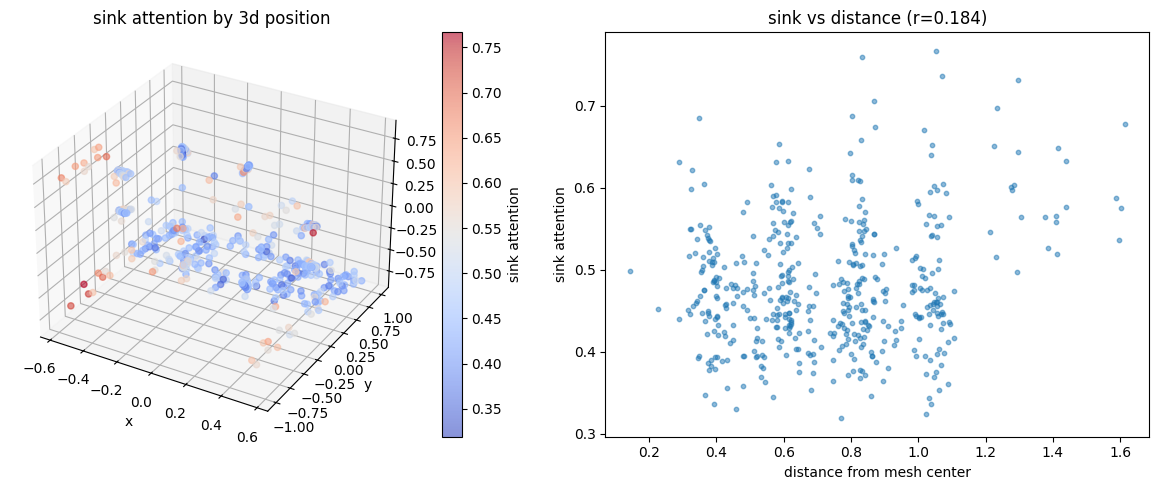

In [7]:
# left: sink attention colored on the 3d positions, right: sink vs distance from center
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
sc = ax1.scatter(
    query_positions[:, 0], query_positions[:, 1], query_positions[:, 2],
    c=sink_attentions, cmap='coolwarm', alpha=0.6, s=20
)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('sink attention by 3d position')
plt.colorbar(sc, ax=ax1, label='sink attention')

ax2 = fig.add_subplot(122)
ax2.scatter(distances_from_center, sink_attentions, alpha=0.5, s=10)
ax2.set_xlabel('distance from mesh center')
ax2.set_ylabel('sink attention')
ax2.set_title(f'sink vs distance (r={corr_dist:.3f})')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sink_vs_spatial_position.png', dpi=150)
plt.show()

## experiment 2: do triangles attend more to nearby triangles

- purpose: test whether attention weight falls off with spatial distance between the query triangle and each attended triangle
- method: every non sink token is paired with its distance to the query center, the pairs are binned into 20 distance bins and averaged, and the raw pairs are correlated with `pearsonr`
- output: saves a plot of mean attention per distance bin and prints the correlation between distance and attention

In [8]:
# collect (spatial distance, attention weight) pairs for every non sink token
spatial_dist_vs_attn = []

for step, layers in captured_attentions.items():
    query_tri = step // 9

    if query_tri < 2 or query_tri >= len(centroids):
        continue

    attn = layers[last_layer]
    query_centroid = centroids[query_tri - 1]

    # walk the attended tokens past the sink block
    for token_pos in range(10, len(attn)):
        tri_idx = (token_pos - 1) // 9

        if tri_idx >= len(centroids):
            continue

        dist = np.linalg.norm(query_centroid - centroids[tri_idx])
        weight = attn[token_pos]
        spatial_dist_vs_attn.append((dist, weight))

spatial_dist_vs_attn = np.array(spatial_dist_vs_attn)
print(f'collected {len(spatial_dist_vs_attn)} pairs')

collected 1082646 pairs


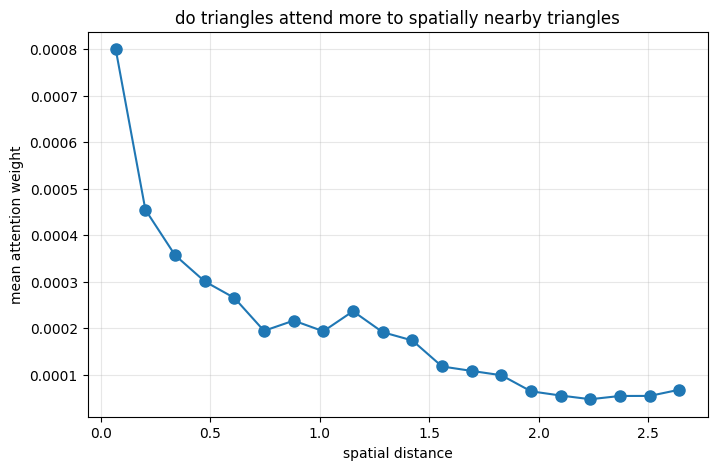

correlation: r=-0.1444, p=0.0000


In [9]:
# bin the pairs by distance and average the attention in each bin
n_bins = 20
max_dist = spatial_dist_vs_attn[:, 0].max()
dist_bins = np.linspace(0, max_dist, n_bins + 1)

bin_means = []
bin_centers = []

for i in range(n_bins):
    mask = (spatial_dist_vs_attn[:, 0] >= dist_bins[i]) & (spatial_dist_vs_attn[:, 0] < dist_bins[i+1])
    if mask.sum() > 0:
        bin_means.append(spatial_dist_vs_attn[mask, 1].mean())
        bin_centers.append((dist_bins[i] + dist_bins[i+1]) / 2)

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, bin_means, 'o-', markersize=8)
plt.xlabel('spatial distance')
plt.ylabel('mean attention weight')
plt.title('do triangles attend more to spatially nearby triangles')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/attention_vs_spatial_distance.png', dpi=150)
plt.show()

corr_spatial, p_spatial = pearsonr(spatial_dist_vs_attn[:, 0], spatial_dist_vs_attn[:, 1])
print(f'correlation: r={corr_spatial:.4f}, p={p_spatial:.4f}')

## experiment 3: where would spatial sinks help most

- purpose: find regions of the mesh where sink attention is higher or lower, which would suggest where a placed sink might matter
- method: the query positions are grouped into 8 clusters with kmeans and the mean sink attention is taken per cluster
- output: prints the mean sink attention per cluster and saves a 3d view of the cluster centers with a bar chart per cluster

In [10]:
# group the query positions into 8 spatial clusters
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(query_positions)
cluster_centers = kmeans.cluster_centers_

# mean sink attention within each cluster
cluster_sink_means = []
for i in range(n_clusters):
    mask = cluster_labels == i
    cluster_sink_means.append(sink_attentions[mask].mean())
cluster_sink_means = np.array(cluster_sink_means)

print('sink attention by spatial region:')
for i in range(n_clusters):
    print(f'  cluster {i}: sink={cluster_sink_means[i]:.3f}')

sink attention by spatial region:
  cluster 0: sink=0.502
  cluster 1: sink=0.503
  cluster 2: sink=0.425
  cluster 3: sink=0.524
  cluster 4: sink=0.466
  cluster 5: sink=0.508
  cluster 6: sink=0.502
  cluster 7: sink=0.443


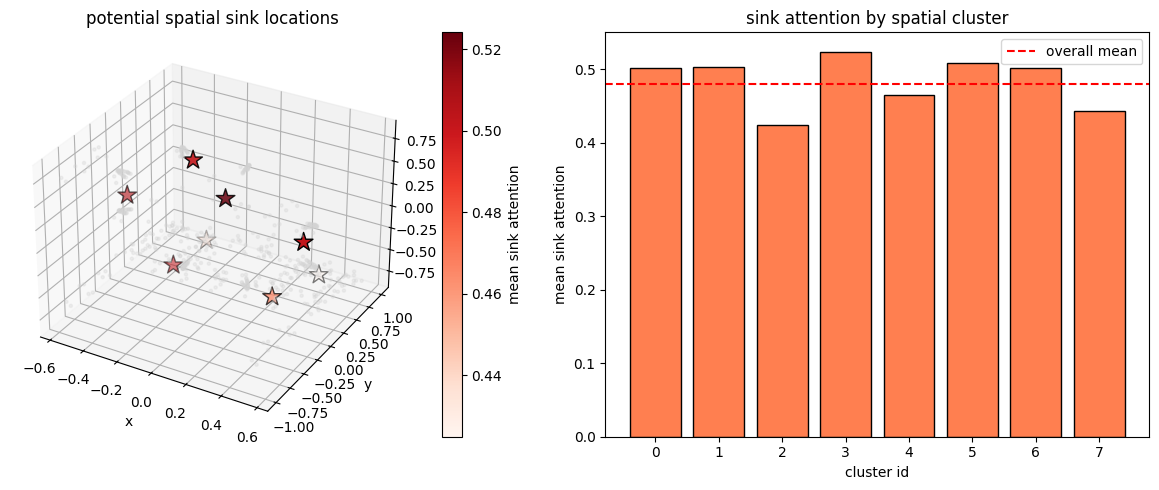

In [11]:
# left: cluster centers over the mesh colored by sink attention, right: sink per cluster
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
            c='lightgray', alpha=0.3, s=5)
sc = ax1.scatter(cluster_centers[:, 0], cluster_centers[:, 1], cluster_centers[:, 2],
                 c=cluster_sink_means, cmap='Reds', s=200, marker='*', edgecolors='black')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('potential spatial sink locations')
plt.colorbar(sc, ax=ax1, label='mean sink attention')

ax2 = fig.add_subplot(122)
ax2.bar(range(n_clusters), cluster_sink_means, color='coral', edgecolor='black')
ax2.axhline(sink_attentions.mean(), color='red', linestyle='--', label='overall mean')
ax2.set_xlabel('cluster id')
ax2.set_ylabel('mean sink attention')
ax2.set_title('sink attention by spatial cluster')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/potential_spatial_sinks.png', dpi=150)
plt.show()

## experiment 4: distance from the current sink

- purpose: test whether sink attention relates to how far a triangle is from the first triangle, which acts as the current sink
- method: distance is measured from each triangle center to the first triangle center, aligned to the sampled steps, and correlated with sink attention
- output: prints the correlation and saves a histogram of distances next to a sink versus distance scatter

In [12]:
# distance from each triangle center to the first triangle, the current sink
first_tri_centroid = centroids[0]
distances_from_sink = np.linalg.norm(centroids - first_tri_centroid, axis=1)

# align the distances to the sampled steps
sampled_distances = []
for step in captured_attentions.keys():
    query_tri = step // 9
    if query_tri >= 1 and query_tri < len(centroids):
        sampled_distances.append(distances_from_sink[query_tri - 1])

sampled_distances = np.array(sampled_distances)

corr_sink_dist, p_sink_dist = pearsonr(sampled_distances, sink_attentions)
print(f'correlation (distance from sink vs sink attention): r={corr_sink_dist:.3f}')

correlation (distance from sink vs sink attention): r=-0.343


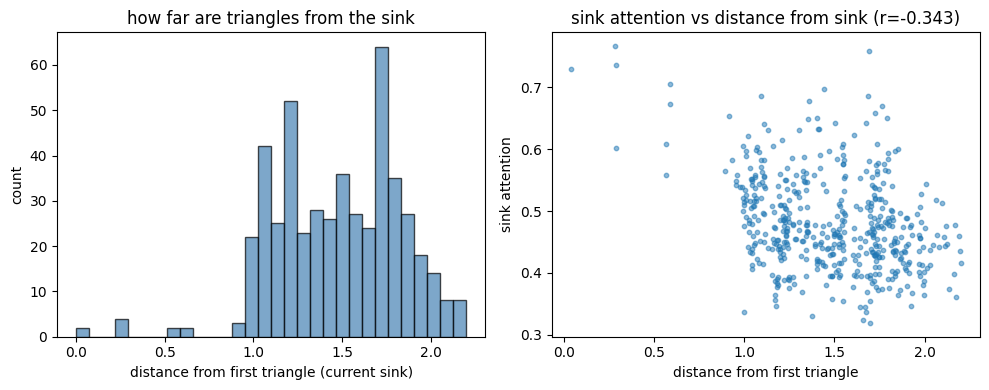

In [13]:
# left: distribution of distances from the sink, right: sink attention vs that distance
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.hist(distances_from_sink, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('distance from first triangle (current sink)')
plt.ylabel('count')
plt.title('how far are triangles from the sink')

plt.subplot(122)
plt.scatter(sampled_distances, sink_attentions, alpha=0.5, s=10)
plt.xlabel('distance from first triangle')
plt.ylabel('sink attention')
plt.title(f'sink attention vs distance from sink (r={corr_sink_dist:.3f})')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distance_from_current_sink.png', dpi=150)
plt.show()

## experiment 5: control for sequence position

- purpose: check whether the distance effect is really a sequence position effect, since early triangles sit near the sink and also have fewer tokens to attend to
- method: sink attention is correlated with the triangle sequence index with `pearsonr`
- output: prints the correlation, saves a sink versus sequence position scatter, and prints a short note on why sequence position can drive the distance result

correlation (sequence position vs sink): r=-0.509


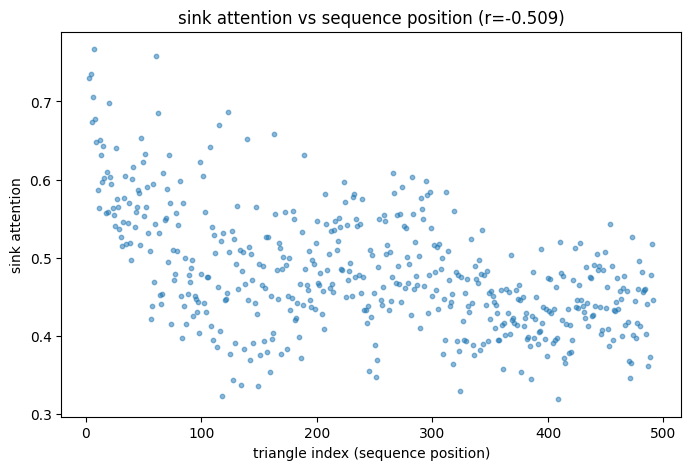


this helps explain the negative correlation with distance from sink:
early triangles (near sink spatially) are also early in sequence
early triangles have fewer tokens to attend to, so more goes to sink


In [14]:
# correlate sink attention with sequence position
corr_seq, p_seq = pearsonr(triangle_indices, sink_attentions)
print(f'correlation (sequence position vs sink): r={corr_seq:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(triangle_indices, sink_attentions, alpha=0.5, s=10)
plt.xlabel('triangle index (sequence position)')
plt.ylabel('sink attention')
plt.title(f'sink attention vs sequence position (r={corr_seq:.3f})')
plt.savefig(f'{OUTPUT_DIR}/sink_vs_sequence_position.png', dpi=150)
plt.show()

print('\nthis helps explain the negative correlation with distance from sink:')
print('early triangles (near sink spatially) are also early in sequence')
print('early triangles have fewer tokens to attend to, so more goes to sink')

## experiment 6: partial correlation controlling for sequence

- purpose: isolate any spatial distance effect after removing the sequence position effect
- method: sequence position is regressed out of both sink attention and distance with a linear fit, and the residuals are correlated, which gives the partial correlation
- output: prints the raw and partial correlations and a note on which effect dominates

In [15]:
# regress sequence position out of both variables, then correlate the residuals
from numpy.polynomial import polynomial as P

# fit sink as a line in sequence position and take the residual
coef_sink = np.polyfit(triangle_indices, sink_attentions, 1)
sink_residuals = sink_attentions - np.polyval(coef_sink, triangle_indices)

# fit distance as a line in sequence position and take the residual
coef_dist = np.polyfit(triangle_indices, sampled_distances, 1)
dist_residuals = sampled_distances - np.polyval(coef_dist, triangle_indices)

# correlation of residuals is the partial correlation
partial_corr, partial_p = pearsonr(dist_residuals, sink_residuals)

print(f'raw correlation (dist from sink vs sink attn): r={corr_sink_dist:.3f}')
print(f'partial correlation (controlling for sequence): r={partial_corr:.3f}')
print()
if abs(partial_corr) < abs(corr_sink_dist) * 0.5:
    print('partial correlation is much weaker')
    print('the raw correlation was largely due to sequence position, not spatial distance')
else:
    print('partial correlation remains strong')
    print('spatial distance has an independent effect beyond sequence position')

raw correlation (dist from sink vs sink attn): r=-0.343
partial correlation (controlling for sequence): r=-0.082

partial correlation is much weaker
the raw correlation was largely due to sequence position, not spatial distance


## experiment 7: do nearby triangles substitute for the sink

- purpose: test whether attention to the nearest triangles trades off against sink attention
- method: for each query the 5 nearest earlier triangles are found by center distance, their attention is summed, aligned with the sink attention over the same subset, and correlated
- output: prints the correlation and the mean attention to the nearest triangles, and saves a sink versus nearest scatter

In [16]:
# for each query find the 5 nearest earlier triangles and sum their attention
k_nearest = 5
nearest_attentions = []

for step, layers in captured_attentions.items():
    query_tri = step // 9

    if query_tri < 10 or query_tri >= len(centroids):
        continue

    attn = layers[last_layer]
    query_centroid = centroids[query_tri - 1]

    # distance from the query center to every earlier triangle, skipping the sink
    distances = []
    for tri_idx in range(1, query_tri - 1):
        dist = np.linalg.norm(query_centroid - centroids[tri_idx])
        distances.append((tri_idx, dist))

    distances.sort(key=lambda x: x[1])
    nearest_tris = [d[0] for d in distances[:k_nearest]]

    # sum attention over the token block of each nearest triangle
    nearest_attn = 0
    for tri_idx in nearest_tris:
        start_pos = 1 + tri_idx * 9
        end_pos = start_pos + 9
        if end_pos <= len(attn):
            nearest_attn += attn[start_pos:end_pos].sum()

    nearest_attentions.append(nearest_attn)

nearest_attentions = np.array(nearest_attentions)

# collect the sink attention over the same subset of steps
sink_subset = []
for step, layers in captured_attentions.items():
    query_tri = step // 9
    if query_tri >= 10 and query_tri < len(centroids):
        attn = layers[last_layer]
        sink_subset.append(attn[:10].sum())

sink_subset = np.array(sink_subset)

corr_sub, p_sub = pearsonr(sink_subset, nearest_attentions)
print(f'correlation (sink vs nearest {k_nearest} triangles): r={corr_sub:.3f}')
print(f'mean attention to nearest triangles: {nearest_attentions.mean():.4f}')

correlation (sink vs nearest 5 triangles): r=0.086
mean attention to nearest triangles: 0.0435


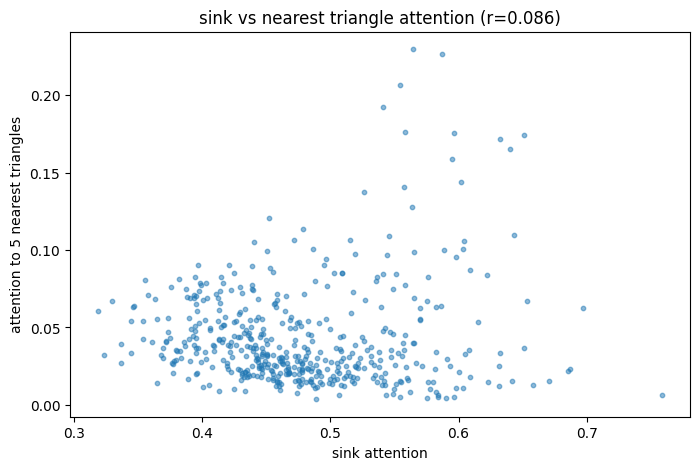

weak correlation: independent usage


In [17]:
# sink attention vs attention to the nearest triangles
plt.figure(figsize=(8, 5))
plt.scatter(sink_subset, nearest_attentions, alpha=0.5, s=10)
plt.xlabel('sink attention')
plt.ylabel(f'attention to {k_nearest} nearest triangles')
plt.title(f'sink vs nearest triangle attention (r={corr_sub:.3f})')
plt.savefig(f'{OUTPUT_DIR}/sink_vs_nearest.png', dpi=150)
plt.show()

# read the sign of the correlation
if corr_sub < -0.15:
    print('negative correlation: nearby triangles substitute for sink')
elif corr_sub > 0.15:
    print('positive correlation: sink and nearby used together')
else:
    print('weak correlation: independent usage')

## place scaffold tokens for the model to attend to

- purpose: rerun generation with 8 scaffold sink tokens added and compare the result to the baseline and logit bias meshes
- method:
  - the embedding table is extended by 8 rows set to copies of the bos vector, and generation places bos then the 8 scaffolds before decoding
  - this run uses kv caching, so only the last token is passed each step
- output: prints the model and scaffold setup, the scaffold triangle count, a metric table, and a three way mesh figure

note: the metric table and the mesh figure read `baseline_mesh_clean`, `spatial_mesh_clean`, and `plot_mesh`, which are not defined in this notebook, so the last two cells stop with a name error as recorded

In [18]:
from types import SimpleNamespace
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from models.mesh_xl.get_model import MeshXL
from types import SimpleNamespace
from tqdm import tqdm
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

# model settings: base llm, coordinate levels, max triangle count
config = SimpleNamespace(
    llm='mesh-xl/mesh-xl-1.3b',
    n_discrete_size=128,
    n_max_triangles=800
)

model = MeshXL(config)
model = model.to(device)
model.eval()

# load the pretrained chair weights, allow missing keys
checkpoint = torch.load('ckpts/meshxl-1.3b-chair.pth', map_location=device)
model.load_state_dict(checkpoint['model'], strict=False)

print('model loaded')

/home/wkt7ne/miniforge3/envs/meshxl311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


Some weights of the model checkpoint at mesh-xl/mesh-xl-1.3b were not used when initializing OPTForCausalLM: ['tokenizer.dummpy_param', 'transformer.lm_head.weight']
- This IS expected if you are initializing OPTForCausalLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing OPTForCausalLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/tmp/ipykernel_632590/3741276597.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for 

model loaded


In [19]:
# keep a copy of the token vectors before extending the table
original_embed = model.transformer.model.decoder.embed_tokens.weight.data.clone()
original_vocab_size = original_embed.shape[0]  # 131
embed_dim = original_embed.shape[1]  # 2048

print(f'original vocab size: {original_vocab_size}')
print(f'embedding dim: {embed_dim}')

# 8 scaffold token ids placed after the existing vocab
n_scaffolds = 8
scaffold_ids = list(range(original_vocab_size, original_vocab_size + n_scaffolds))
print(f'scaffold token ids: {scaffold_ids}')

# scaffold positions at the 8 corners of the unit cube
scaffold_positions = np.array([
    [-1, -1, -1], [1, -1, -1], [-1, 1, -1], [1, 1, -1],
    [-1, -1, 1],  [1, -1, 1],  [-1, 1, 1],  [1, 1, 1]
])
print(f'scaffold positions:\n{scaffold_positions}')

original vocab size: 131
embedding dim: 2048
scaffold token ids: [131, 132, 133, 134, 135, 136, 137, 138]
scaffold positions:
[[-1 -1 -1]
 [ 1 -1 -1]
 [-1  1 -1]
 [ 1  1 -1]
 [-1 -1  1]
 [ 1 -1  1]
 [-1  1  1]
 [ 1  1  1]]


In [20]:
# extend the embedding table to include the scaffold tokens
n_scaffolds = 8
new_vocab_size = original_vocab_size + n_scaffolds  # 139

# larger table sized for the extra tokens
new_embed = torch.nn.Embedding(new_vocab_size, embed_dim).to(device)

# copy the original vectors into the first rows
new_embed.weight.data[:original_vocab_size] = original_embed

# set each scaffold row to a copy of the bos vector
bos_embedding = original_embed[model.bos_token_id]  # token 128
for i in range(n_scaffolds):
    new_embed.weight.data[131 + i] = bos_embedding.clone()

# attach the new table to the model
model.transformer.model.decoder.embed_tokens = new_embed

print(f'new vocab size: {new_vocab_size}')
print('scaffold embeddings initialized as bos copies')

new vocab size: 139
scaffold embeddings initialized as bos copies


In [21]:
def generate_with_scaffolds(model, scaffold_ids, max_triangles=200):
    """generate with the scaffold tokens placed after bos, using kv caching"""
    model.eval()

    # sequence starts with bos then the 8 scaffold tokens
    generated = [model.bos_token_id] + scaffold_ids
    past_key_values = None

    with torch.no_grad():
        for step in tqdm(range(max_triangles * 9), desc='scaffold generation'):
            # first step passes the whole prefix, later steps pass only the last token
            if past_key_values is None:
                input_ids = torch.tensor([generated], device=device)
            else:
                input_ids = torch.tensor([[generated[-1]]], device=device)

            outputs = model.transformer(
                input_ids=input_ids,
                past_key_values=past_key_values,
                use_cache=True
            )
            past_key_values = outputs.past_key_values

            # greedy next token
            logits = outputs.logits[0, -1, :]
            next_token = logits.argmax().item()

            if next_token == model.eos_token_id:
                break

            generated.append(next_token)

    # drop bos and the scaffolds, return triangle tokens only
    return generated[1 + len(scaffold_ids):]

scaffold_ids = [131, 132, 133, 134, 135, 136, 137, 138]
print('generating with scaffold tokens...')
scaffold_tokens = generate_with_scaffolds(model, scaffold_ids, max_triangles=500)
scaffold_tokens = np.array(scaffold_tokens)
scaffold_mesh = tokens_to_triangles(scaffold_tokens)
print(f'scaffold-based: {len(scaffold_mesh)} triangles')

generating with scaffold tokens...


scaffold generation:  36%|███▌      | 1612/4500 [02:24<04:19, 11.14it/s]

scaffold-based: 179 triangles


In [25]:
def compute_mesh_metrics(triangles):
    """compute mesh quality numbers"""
    metrics = {}

    metrics['n_triangles'] = len(triangles)

    all_coords = triangles.reshape(-1, 3)
    bbox_min = all_coords.min(axis=0)
    bbox_max = all_coords.max(axis=0)
    bbox_size = bbox_max - bbox_min
    metrics['bbox_volume'] = np.prod(bbox_size)

    areas = []
    for tri in triangles:
        v0, v1, v2 = tri
        area = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))
        areas.append(area)
    metrics['mean_area'] = np.mean(areas)
    metrics['std_area'] = np.std(areas)

    centroids = triangles.mean(axis=1)
    consecutive_dists = []
    for i in range(1, len(centroids)):
        dist = np.linalg.norm(centroids[i] - centroids[i-1])
        consecutive_dists.append(dist)
    metrics['mean_consecutive_dist'] = np.mean(consecutive_dists)

    metrics['centroid_spread'] = np.std(centroids)

    return metrics

# keep only triangles with no nan
valid_mask = ~np.isnan(scaffold_mesh).any(axis=(1,2))
scaffold_mesh_clean = scaffold_mesh[valid_mask]

scaffold_metrics = compute_mesh_metrics(scaffold_mesh_clean)

print('scaffold mesh metrics:')
for key in scaffold_metrics:
    print(f'{key:<25} {scaffold_metrics[key]:>12.4f}')

scaffold mesh metrics:
n_triangles                   179.0000
bbox_volume                     6.2362
mean_area                       0.0972
std_area                        0.2683
mean_consecutive_dist           0.5380
centroid_spread                 0.7107


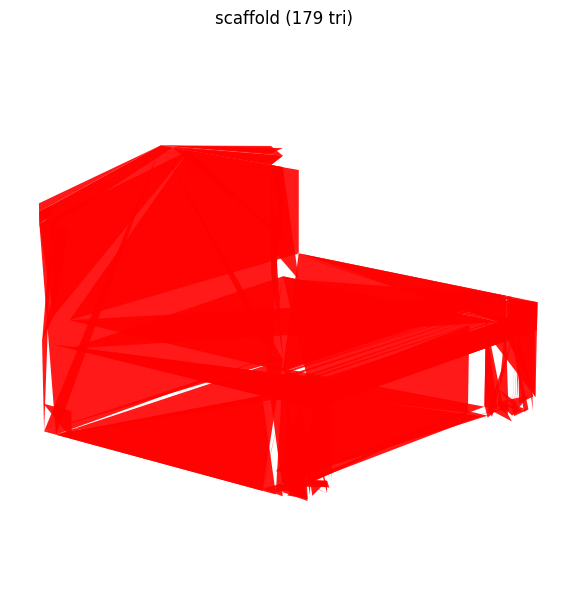

In [26]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_mesh(ax, triangles, title, color='blue'):
    # triangles is shape (n, 3, 3), each row is one triangle with 3 vertices
    mesh = Poly3DCollection(triangles, alpha=0.9)
    mesh.set_facecolor(color)
    mesh.set_edgecolor('none')
    ax.add_collection3d(mesh)

    all_coords = triangles.reshape(-1, 3)
    ax.set_xlim(all_coords[:, 0].min(), all_coords[:, 0].max())
    ax.set_ylim(all_coords[:, 1].min(), all_coords[:, 1].max())
    ax.set_zlim(all_coords[:, 2].min(), all_coords[:, 2].max())
    ax.set_title(title)
    ax.set_axis_off()
    ax.view_init(elev=15, azim=-50)

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(111, projection='3d')
plot_mesh(ax, scaffold_mesh_clean, f'scaffold ({len(scaffold_mesh_clean)} tri)', color='red')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/scaffold_comparison.png', dpi=150)
plt.show()